In [1]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

pd.set_option("display.max_columns", 50)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path("../../").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "ecg" / "ptbxl"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "eda" / "ptbxl"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset directory:", DATA_DIR)
print("Artifact directory:", ARTIFACT_DIR)

Dataset directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\ecg\ptbxl
Artifact directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\ptbxl


In [3]:
database_file = DATA_DIR / "ptbxl_database.csv"
scp_file = DATA_DIR / "scp_statements.csv"

print("PTB-XL database:", database_file.exists())
print("SCP statements :", scp_file.exists())

if not database_file.exists():
    raise FileNotFoundError(
        f"Missing file: {database_file}"
    )

if not scp_file.exists():
    raise FileNotFoundError(
        f"Missing file: {scp_file}"
    )

print("\nPTB-XL files found successfully.")

PTB-XL database: True
SCP statements : True

PTB-XL files found successfully.


In [4]:
ptbxl = pd.read_csv(database_file, index_col=0)
scp = pd.read_csv(scp_file, index_col=0)

print(f"PTB-XL records : {len(ptbxl):,}")
print(f"PTB-XL columns : {ptbxl.shape[1]:,}")
print(f"SCP statements : {len(scp):,}")

display(ptbxl.head())

PTB-XL records : 21,837
PTB-XL columns : 27
SCP statements : 71


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,scp_codes,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [5]:
schema = pd.DataFrame({
    "column": ptbxl.columns,
    "dtype": ptbxl.dtypes.astype(str),
    "missing": ptbxl.isna().sum().values,
    "unique": [
        ptbxl[column].nunique(dropna=True)
        for column in ptbxl.columns
    ]
})

display(schema)

,column,dtype,missing,unique
patient_id,patient_id,float64,0,18885
age,age,float64,89,94
sex,sex,int64,0,2
height,height,float64,14854,77
weight,weight,float64,12408,127
nurse,nurse,float64,1509,12
site,site,float64,18,51
device,device,object,0,11
recording_date,recording_date,object,0,21813
report,report,object,0,9883


In [6]:
patient_count = ptbxl["patient_id"].nunique()

duplicate_rows = ptbxl.duplicated().sum()

print(f"ECG recordings : {len(ptbxl):,}")
print(f"Unique patients: {patient_count:,}")
print(f"Duplicate rows : {duplicate_rows:,}")

if "age" in ptbxl.columns:
    print(f"\nAge range      : {ptbxl['age'].min()} - {ptbxl['age'].max()}")

if "sex" in ptbxl.columns:
    print("\nSex distribution:")
    display(ptbxl["sex"].value_counts(dropna=False).to_frame("count"))

ECG recordings : 21,837
Unique patients: 18,885
Duplicate rows : 0

Age range      : 2.0 - 95.0

Sex distribution:


,count
sex,
0,11379
1,10458


In [7]:
def parse_scp_codes(value):
    if pd.isna(value):
        return {}
    
    if isinstance(value, dict):
        return value
    
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return {}


ptbxl["scp_codes_parsed"] = ptbxl["scp_codes"].apply(parse_scp_codes)

print("Example parsed annotation:")
print(ptbxl["scp_codes_parsed"].iloc[0])

Example parsed annotation:
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


,count,percentage
NORM,9528,43.63
MI,0,0.00
STTC,0,0.00
CD,0,0.00
HYP,0,0.00


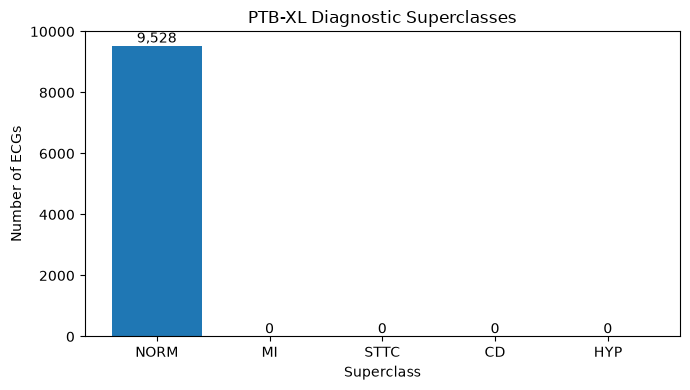

In [8]:
diagnostic_superclasses = ["NORM", "MI", "STTC", "CD", "HYP"]

diagnostic_counts = {
    label: 0
    for label in diagnostic_superclasses
}

for codes in ptbxl["scp_codes_parsed"]:
    for label in diagnostic_superclasses:
        if label in codes:
            diagnostic_counts[label] += 1

diagnostic_summary = pd.DataFrame(
    {
        "count": diagnostic_counts
    }
).sort_values(
    "count",
    ascending=False
)

diagnostic_summary["percentage"] = (
    diagnostic_summary["count"] / len(ptbxl) * 100
).round(2)

display(diagnostic_summary)

plt.figure(figsize=(7, 4))

plt.bar(
    diagnostic_summary.index,
    diagnostic_summary["count"]
)

plt.title("PTB-XL Diagnostic Superclasses")
plt.xlabel("Superclass")
plt.ylabel("Number of ECGs")

for i, count in enumerate(diagnostic_summary["count"]):
    plt.text(
        i,
        count,
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [9]:
rhythm_labels = [
    "SR",
    "AFIB",
    "AFLT",
    "STACH",
    "SBRAD",
    "SARRH",
    "PSVT",
    "BIGU",
    "PACE",
]

rhythm_counts = {
    label: 0
    for label in rhythm_labels
}

for codes in ptbxl["scp_codes_parsed"]:
    for label in rhythm_labels:
        if label in codes:
            rhythm_counts[label] += 1

rhythm_summary = pd.DataFrame({
    "count": rhythm_counts
})

rhythm_summary["percentage"] = (
    rhythm_summary["count"] / len(ptbxl) * 100
).round(2)

rhythm_summary = rhythm_summary.sort_values(
    "count",
    ascending=False
)

display(rhythm_summary)

,count,percentage
SR,16782,76.85
AFIB,1514,6.93
STACH,826,3.78
SARRH,772,3.54
SBRAD,637,2.92
PACE,296,1.36
BIGU,82,0.38
AFLT,73,0.33
PSVT,24,0.11


In [10]:
ptbxl["label_count"] = ptbxl["scp_codes_parsed"].apply(len)

print(
    "Average annotations per ECG:",
    round(ptbxl["label_count"].mean(), 2)
)

print(
    "Maximum annotations on one ECG:",
    ptbxl["label_count"].max()
)

print("\nLabel-count distribution:")
display(
    ptbxl["label_count"]
    .value_counts()
    .sort_index()
    .to_frame("ecg_count")
)

Average annotations per ECG: 2.8
Maximum annotations on one ECG: 9

Label-count distribution:


,ecg_count
label_count,
1,705
2,11247
3,5114
4,2597
5,1254
6,597
7,253
8,63
9,7


In [11]:
filename_column = None

if "filename_lr" in ptbxl.columns:
    filename_column = "filename_lr"
elif "filename_hr" in ptbxl.columns:
    filename_column = "filename_hr"

if filename_column is None:
    raise KeyError(
        "Neither 'filename_lr' nor 'filename_hr' was found in ptbxl_database.csv."
    )

sample_record = ptbxl.iloc[0][filename_column]

record_path = DATA_DIR / sample_record

print("Using recording:")
print(record_path)

signal, fields = wfdb.rdsamp(str(record_path))

print("\nSignal shape:", signal.shape)
print("Sampling frequency:", fields["fs"])
print("Number of channels:", fields["n_sig"])
print("Signal names:", fields["sig_name"])

Using recording:
D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\ecg\ptbxl\records100\00000\00001_lr

Signal shape: (1000, 12)
Sampling frequency: 100
Number of channels: 12
Signal names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


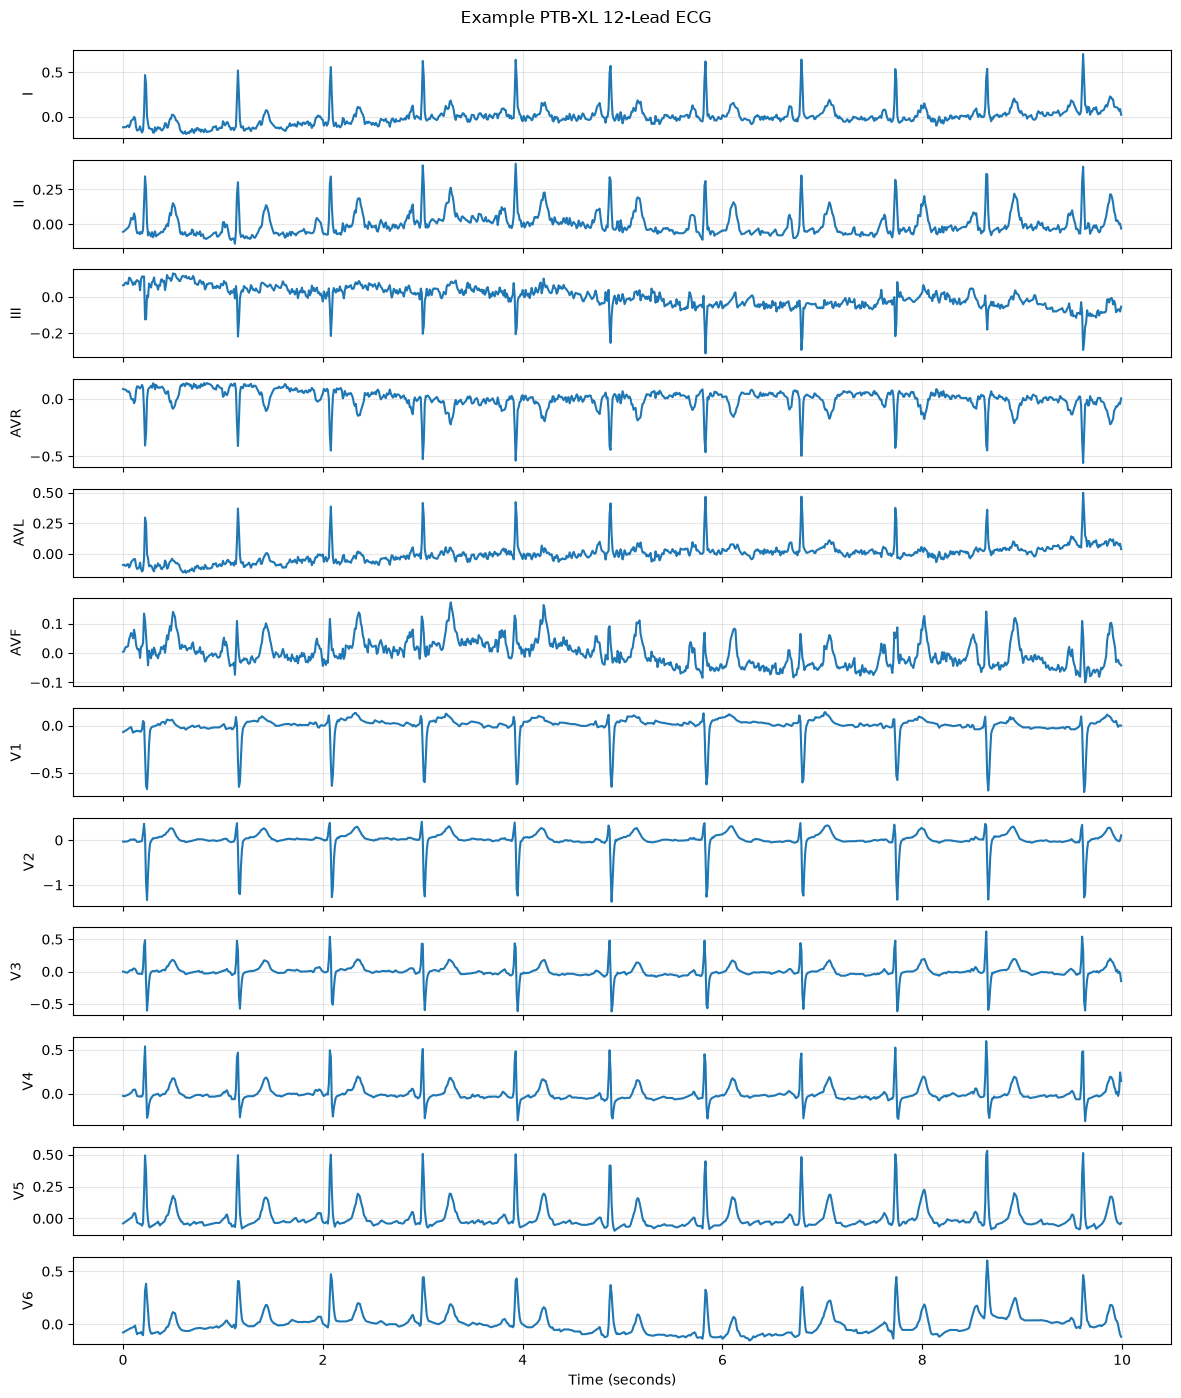

In [12]:
lead_names = fields["sig_name"]

time = np.arange(signal.shape[0]) / fields["fs"]

fig, axes = plt.subplots(
    len(lead_names),
    1,
    figsize=(12, 14),
    sharex=True
)

for i, lead in enumerate(lead_names):
    axes[i].plot(time, signal[:, i])
    axes[i].set_ylabel(lead)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle("Example PTB-XL 12-Lead ECG", y=0.995)

plt.tight_layout()
plt.show()

In [13]:
signal_summary = pd.DataFrame({
    "lead": lead_names,
    "min": np.min(signal, axis=0),
    "max": np.max(signal, axis=0),
    "mean": np.mean(signal, axis=0),
    "std": np.std(signal, axis=0),
})

display(signal_summary.round(4))

print("NaN values:", np.isnan(signal).sum())
print("Infinite values:", np.isinf(signal).sum())

,lead,min,max,mean,std
0,I,-0.195,0.706,0.0015,0.1090
1,II,-0.140,0.435,0.0007,0.0832
2,III,-0.312,0.130,-0.0008,0.0587
3,AVR,-0.559,0.138,-0.0011,0.0924
4,AVL,-0.155,0.500,0.0012,0.0770
5,AVF,-0.100,0.172,0.0000,0.0469
6,V1,-0.704,0.142,-0.0017,0.1131
7,V2,-1.377,0.410,0.0070,0.2142
8,V3,-0.618,0.620,-0.0018,0.1178
9,V4,-0.315,0.599,-0.0041,0.0954


NaN values: 0
Infinite values: 0


In [14]:
diagnostic_summary.to_csv(
    ARTIFACT_DIR / "diagnostic_superclasses.csv"
)

rhythm_summary.to_csv(
    ARTIFACT_DIR / "rhythm_distribution.csv"
)

signal_summary.to_csv(
    ARTIFACT_DIR / "sample_signal_summary.csv",
    index=False
)

eda_summary = {
    "dataset": "PTB-XL",
    "recordings": int(len(ptbxl)),
    "patients": int(ptbxl["patient_id"].nunique()),
    "duplicate_rows": int(duplicate_rows),
    "average_annotations_per_record": float(
        ptbxl["label_count"].mean()
    ),
    "max_annotations_per_record": int(
        ptbxl["label_count"].max()
    ),
    "sample_sampling_frequency": float(fields["fs"]),
    "sample_lead_count": int(fields["n_sig"]),
    "sample_has_nan": bool(np.isnan(signal).any()),
    "sample_has_inf": bool(np.isinf(signal).any()),
}

pd.DataFrame([eda_summary]).to_json(
    ARTIFACT_DIR / "eda_summary.json",
    orient="records",
    indent=2
)

print("PTB-XL EDA completed.")
print("\nSummary:")
print(eda_summary)

PTB-XL EDA completed.

Summary:
{'dataset': 'PTB-XL', 'recordings': 21837, 'patients': 18885, 'duplicate_rows': 0, 'average_annotations_per_record': 2.7988734716307184, 'max_annotations_per_record': 9, 'sample_sampling_frequency': 100.0, 'sample_lead_count': 12, 'sample_has_nan': False, 'sample_has_inf': False}
